# Assumption Notes

Include notes of possible diagnostics by assumption.

Here's the simulated Harmon's data...

In [1]:
# make sure the output folder exists before the writes below
import os
os.makedirs('data', exist_ok=True)

In [2]:
import os
import numpy as np
import polars as pl
import seaborn.objects as so

# Randomization seed
rng = np.random.default_rng(42)

# Parameter values
n = 4_793
beta_0 = 0.05
beta_jif = 0.20
beta_skippy = 0.15
beta_peterpan = -0.05
beta_harmons = 0.10
beta_coupon = 0.12
beta_ad = 0.08
beta_loyal = 0.15
beta_log_price = -0.90
beta_texture_smooth = 0.10
beta_texture_chunky = -0.10
beta_log_size = 0.10
beta_lp_x_coupon = 0.15
beta_loyal_x_coupon = 0.05
beta_harmons_x_ad = 0.06
beta_jif_x_smooth = 0.05
beta_age = -0.01
beta_log_avg_spend = 0.50
sigma = 0.15

# Customer IDs
cust_ids = np.array([f'C{str(i).zfill(5)}' for i in range(1, n+1)])
rng.shuffle(cust_ids)

# Brands
brands = np.array(['None', 'Jif', 'Skippy', 'PeterPan', 'Harmons'])
brand_probs = np.array([0.40, 0.25, 0.10, 0.05, 0.20])
brand = rng.choice(brands, size=n, p=brand_probs)

# Promotions and loyalty
coupon = rng.binomial(1, 0.30, size=n)
ad = rng.binomial(1, 0.20, size=n)
loyal = rng.binomial(1, 0.40, size=n)

# Texture
texture = rng.choice(np.array(['Smooth', 'Chunky']), size=n, p=[0.65, 0.35])

# Jar size (oz)
size_choices = np.array([12, 16])
size_probs   = np.array([0.30, 0.70])
size = rng.choice(size_choices, size=n, p=size_probs)

# Price by brand and size
price_per_oz = {'None': 0, 'Jif': 0.37, 'Skippy': 0.32, 'PeterPan': 0.30, 'Harmons': 0.20}
price = np.array([
    (price_per_oz[b] * s) for b, s in zip(brand, size)
]).round(2)

# Define different coupon discount rates
discount_rates = np.array([0.10, 0.15, 0.20, 0.25])
discount_probs = np.array([0.40, 0.35, 0.20, 0.05])

# Randomly assign discount rates to each observation
coupon_discount_rate = rng.choice(discount_rates, size=n, p=discount_probs)

# Only apply discount if coupon present and product purchased
price_with_coupon = np.where(
    (coupon == 1) & (brand != 'None'),
    price * (1 - coupon_discount_rate),
    price
).round(2)

# Update the price variable
price = price_with_coupon

# Generate customer ages only for loyal customers
loyal_customer_ages = rng.normal(loc=42, scale=12, size=n)
loyal_customer_ages = np.clip(loyal_customer_ages, 18, 80).round(0).astype(int)

# Average monthly grocery spend (household size proxy)
loyal_avg_spend = rng.lognormal(mean=np.log(180), sigma=0.4, size=n)
loyal_avg_spend = np.clip(loyal_avg_spend, 50, 800).round(0).astype(int)

# Gender - categorical
loyal_gender = rng.choice(['M', 'F', 'Other'], size=n, p=[0.45, 0.52, 0.03])

# Loyalty points earned
loyal_points = rng.exponential(scale=2500, size=n).round(0).astype(int)
loyal_points = np.clip(loyal_points, 0, 15000) # Cap at 15,000 points

# Email preferences
loyal_email_pref = rng.choice(['Yes', 'No'], size=n, p=[0.75, 0.25])

# Clean data for non-buyers
mask_none = (brand == 'None')
texture[mask_none] = 'None'
size[mask_none] = 0
price[mask_none] = 0.0

# Clean data for loyal customers
customer_age = np.where(loyal == 1, loyal_customer_ages, np.nan)
customer_avg_spend = np.where(loyal == 1, loyal_avg_spend, np.nan)
customer_gender = np.where(loyal == 1, loyal_gender, "None")
customer_points = np.where(loyal == 1, loyal_points, np.nan)
customer_email = np.where(loyal == 1, loyal_email_pref, "None")

# Create data frame
raw_df = pl.DataFrame({
    'customer_id': cust_ids,
    'brand': brand,
    'coupon': coupon,
    'ad': ad,
    'loyal': loyal,
    'texture': texture,
    'size': size,
    'price': price,
    'age': customer_age,
    'avg_spend': customer_avg_spend,
    'gender': customer_gender,
    'points': customer_points,
    'email': customer_email,
})

# Dummy code data frame
X_df = raw_df.to_dummies(
    columns = ['brand', 'texture']
).with_columns(
    # Composite promo flag
    ((pl.col('coupon') + pl.col('ad')) > 0).alias('promo'),
    # Log price, size, and avg_spend
    pl.when(pl.col('price') > 0).then(pl.col('price').log()).otherwise(0.0).alias('log_price'),
    pl.when(pl.col('size') > 0).then(pl.col('size').log()).otherwise(0.0).alias('log_size'),
    pl.when(pl.col('avg_spend') > 0).then(pl.col('avg_spend').log()).otherwise(0.0).alias('log_avg_spend'),
).with_columns(
    # Interactions
    (pl.col('log_price') * pl.col('coupon')).alias('logprice_x_coupon'),
    (pl.col('loyal') * pl.col('coupon')).alias('loyal_x_coupon'),
    (pl.col('ad') * pl.col('brand_Harmons')).alias('harmons_x_ad'),
    (pl.col('brand_Jif') * pl.col('texture_Smooth')).alias('jif_x_smooth')
)

# Units and sales
X_df = X_df.with_columns(
    (
        beta_0
        + beta_jif *pl.col('brand_Jif')
        + beta_skippy * pl.col('brand_Skippy')
        + beta_peterpan * pl.col('brand_PeterPan')
        + beta_harmons * pl.col('brand_Harmons')
        + beta_coupon * pl.col('coupon')
        + beta_ad * pl.col('ad')
        + beta_loyal * pl.col('loyal')
        + beta_log_price * pl.col('log_price')
        + beta_log_size * pl.col('log_size')
        + beta_texture_smooth * pl.col('texture_Smooth')
        + beta_texture_chunky * pl.col('texture_Chunky')
        + beta_lp_x_coupon * pl.col('logprice_x_coupon')
        + beta_loyal_x_coupon * pl.col('loyal_x_coupon')
        + beta_harmons_x_ad * pl.col('harmons_x_ad')
        + beta_jif_x_smooth * pl.col('jif_x_smooth')
        + beta_age * pl.col('age').fill_null(0)
        + beta_log_avg_spend * pl.col('log_avg_spend').fill_null(0)
        + rng.normal(0.0, sigma, size=n)
    ).alias('raw_log_units')
).with_columns(
    # Clean log_units and units for non-buyers
    pl.when(pl.col('brand_None') == 1)
        .then(1)
        .otherwise(pl.col('raw_log_units'))
        .alias('log_units')
).with_columns(
    # Exponentiate units and round
    pl.when(pl.col('brand_None') == 1)
        .then(0)
        .otherwise(pl.col('log_units').exp().round(0))
        .alias('units')
).with_columns(
    # Sales
    (pl.col('units') * pl.col('price')).alias('sales'),
)

# Update raw data frame, write
raw_df = raw_df.with_columns(X_df['units', 'sales', 'promo'])

# Write data frames
raw_df.write_parquet(os.path.join('data', 'original_df.parquet'))
X_df.write_parquet(os.path.join('data', 'X_df.parquet'))

# Add missing values at random
missing_loyal_mask = rng.choice([True, False], size=n, p=[0.05, 0.95])
missing_size_mask = rng.choice([True, False], size=n, p=[0.02, 0.98])

# Add common brand name typos
brand_variations = {
    'Jif': ['JIF', 'Jiff'],
    'Skippy': ['SKIPPY', 'Skipy', 'Skipp'],
    'PeterPan': ['Peter Pan'],
    'Harmons': ['Harmon\'s']
}

brand_messy = brand.copy()
for i in range(len(brand_messy)):
    if brand_messy[i] in brand_variations and rng.random() < 0.03:
        brand_messy[i] = rng.choice(brand_variations[brand_messy[i]])

# Add numeric data stored as strings
price_str = price.astype(str)

# Recreate the data frame
raw_df = pl.DataFrame({
    'customer_id': cust_ids,
    'units': X_df['units'],
    'sales': X_df['sales'],
    'brand': brand_messy,
    'promo': X_df['promo'],
    'coupon': coupon,
    'ad': ad,
    'loyal': np.where(missing_loyal_mask, 'None', loyal),
    'texture': texture,
    'size': np.where(missing_size_mask, 'None', size),
    'price': price_str,
    'age': customer_age,
    'avg_spend': customer_avg_spend,
    'gender': customer_gender,
    'points': customer_points,
    'email': customer_email,
})

# Duplicate observations
buyers_mask = raw_df.filter(pl.col('brand') != 'None')
n_duplicates = int(len(buyers_mask) * 0.001)

# Randomly select observations to duplicate and add to the dataset
duplicate_indices = rng.choice(len(buyers_mask), size=n_duplicates, replace=False)
rows_to_duplicate = buyers_mask.slice(duplicate_indices[0], len(duplicate_indices))
raw_df = pl.concat([raw_df, rows_to_duplicate])

# Split into transaction and loyalty data
transaction_df = raw_df.select([
    'customer_id',
    'units',
    'sales',
    'brand',
    'promo',
    'coupon',
    'ad',
    'loyal',
    'texture',
    'size',
    'price'
])

loyalty_df = (raw_df.select([
    'customer_id',
    'units',
    'loyal',
    'age',
    'avg_spend',
    'gender',
    'points',
    'email'
]).filter(pl.col('loyal') == '1'))

# Write data frames
transaction_df.write_parquet(os.path.join('data', 'soft_launch.parquet'))
loyalty_df.write_parquet(os.path.join('data', 'loyalty.parquet'))

## Notes

These notes are just a running list of ways to check each modeling assumption, using the same Harmon's peanut butter data we've been working with. The idea is that once we've fit a model, we want to look at the leftover errors (the residuals) and a few plots to make sure the model is behaving the way it's supposed to. Most of these are the same checks from the linear regression walkthrough in Exercise 10 -- the partial regression plots for linearity, the residuals-vs-fitted cloud for constant variance, the Q-Q plot for normality, and the VIF table for spotting predictors that step on each other (like when `log_avg_spend` and `log_points` blew up because they were tied to `log_age`).

The one new wrinkle is that we want these checks to also work for logistic regression, not just plain linear regression. That's the whole point of the package we're building -- Python doesn't have a clean way to do this yet. For linear models the residuals should look normal and evenly spread; for logistic models they won't, so instead we use a trick (quantile residuals) that reshapes them onto a common scale so the same plots and tests still make sense. Each section below shows the linear version we already know from class, and then the logistic version right next to it.

### Setup for the checks below

Everything below assumes we've already fit a model. Here `fit` is a model fit to the soft-launch data using the same steps as Exercise 10 (clean it up, log the skewed columns like price and age, dummy-code the categoricals, then fit with `statsmodels`). `X` is just the predictors and `y` is the outcome. The cell below loads the tools we need and defines one small helper -- `rq_resid` -- which is the "reshaping" trick that lets the logistic checks reuse the linear-regression plots.

In [3]:
import numpy as np, scipy.stats as st
import statsmodels.api as sm
from statsmodels.stats.diagnostic import (
    het_breuschpagan, het_white, acorr_breusch_godfrey, acorr_ljungbox,
    linear_harvey_collier, linear_rainbow, normal_ad)
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor


def rq_resid(y, mu, family="poisson", n=None, rng=0):
    """Randomized quantile residuals. ~Uniform(0,1) when the model is correct.
    Lets the logistic/GLM checks below reuse the same plots as linear regression."""
    rng = np.random.default_rng(rng)
    if family == "poisson":
        a, b = st.poisson.cdf(y - 1, mu), st.poisson.cdf(y, mu)
    elif family == "bernoulli":              # logistic; mu = P(y = 1)
        a, b = np.where(y == 1, 1 - mu, 0.0), np.where(y == 1, 1.0, 1 - mu)
    elif family == "binomial":               # n trials per row
        a, b = st.binom.cdf(y - 1, n, mu), st.binom.cdf(y, n, mu)
    return rng.uniform(a, b)                  # feed to KS test / Q-Q plot

### Fit the models the checks run on

The checks below need a fitted model to look at. The first cell rebuilds the linear model from Exercise 10 -- clean the soft-launch data, log the skewed columns, dummy-code the categoricals, and fit with `statsmodels` -- and stores it as `fit`, with the predictors in `X` and the outcome in `y`. The R-squared comes out around 0.57, same as in class.

The second cell fits a small logistic model as well, *only* so the logistic versions of the checks have something to run on. It isn't part of the class analysis -- it just predicts a made-up "high demand" flag (units above the median) from the same predictors.

In [4]:
import os
import polars as pl
import statsmodels.formula.api as smf

# tidy up the messy brand spellings, same as Exercise 10
brand_names = {
    'JIF': 'Jif', 'Jiff': 'Jif',
    'SKIPPY': 'Skippy', 'Skipy': 'Skippy', 'Skipp': 'Skippy',
    'Peter Pan': 'PeterPan',
    "Harmon's": 'Harmons',
}

sl_data = pl.read_parquet(os.path.join('data', 'soft_launch.parquet'))

pb_data = (sl_data
    .with_columns(pl.col('brand').cast(pl.Utf8).replace(brand_names).alias('brand'))
    .drop_nans(['units', 'sales'])
    .remove(
        (pl.col('brand') == "None") | (pl.col('loyal') == "None") |
        (pl.col('texture') == "None") | (pl.col('size') == "None")
    )
    .with_columns([
        pl.col('price').cast(pl.Float64).alias('price'),
        pl.col('loyal').cast(pl.Int64).alias('loyal'),
        pl.col('promo').cast(pl.Int64).alias('promo'),
    ])
    .unique()
    .filter(pl.col('units') > 0)
)

# log the skewed columns, dummy-code the categoricals, drop one level of each
pb_train = (pb_data
    .with_columns([
        (pl.col('units') + 1).log().alias('log_units'),
        (pl.col('price') + 1).log().alias('log_price'),
    ])
    .to_dummies(columns=['brand', 'texture', 'size'], drop_first=False)
    .select(pl.exclude('units', 'price', 'brand_Jif', 'texture_Smooth', 'size_16'))
    .to_pandas()
)

predictors = ['brand_Harmons', 'brand_PeterPan', 'brand_Skippy',
              'coupon', 'ad', 'texture_Chunky', 'size_12', 'log_price']

fit = smf.ols('log_units ~ ' + ' + '.join(predictors), data=pb_train).fit()
X = pb_train[predictors]     # predictors only -- used by the VIF check
y = pb_train['log_units']    # the outcome
fit.summary()                # same table as Exercise 10 (R-squared ~ 0.57)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_units   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.564
Method:                 Least Squares   F-statistic:                     178.2
Date:                Tue, 28 Jul 2026   Prob (F-statistic):          1.01e-191
Time:                        19:09:41   Log-Likelihood:                 13.242
No. Observations:                1095   AIC:                            -8.484
Df Residuals:                    1086   BIC:                             36.50
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.1047      0.554      3.799      0.000       1.018       3.192
brand_Harmons      0.1958      0.140      1.398      0.162      -0.079       0.471
brand_PeterPan    -0.1350      0.059     -2.295      0.022      -0.250      -0.020
brand_Skippy       0.0064      0.040      0.161      0.872      -0.071       0.084
coupon             0.3860      0.039      9.923      0.000       0.310       0.462
ad                 0.0772      0.018      4.358      0.000       0.042       0.112
texture_Chunky    -0.1833      0.015    -12.138      0.000      -0.213      -0.154
size_12            0.1479      0.067      2.215      0.027       0.017       0.279
log_price         -0.2471      0.287     -0.860      0.390      -0.811       0.317
==============================================================================
Omnibus:                        1.093   Durbin-Watson:                   2.095
Prob(Omnibus):                  0.579   Jarque-Bera (JB):                0.971
Skew:                          -0.058   Prob(JB):                        0.615
Kurtosis:                       3.088   Cond. No.                         182.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [5]:
# A quick logistic model, ONLY so the logistic checks below have something to run on.
# This is NOT part of the class analysis -- it just predicts a made-up "high demand"
# flag (units above the median) from the same predictors.
pb_train['high_units'] = (pb_train['log_units'] > pb_train['log_units'].median()).astype(int)
logit_predictors = ['coupon', 'ad', 'texture_Chunky', 'size_12', 'log_price']
fit_logit = smf.logit('high_units ~ ' + ' + '.join(logit_predictors),
                      data=pb_train).fit(disp=0)
y_logit = pb_train['high_units'].to_numpy()

## Validity

Validity is really just asking: are we even modeling the right thing, and did we leave anything important out? There's no plot or test for this -- it's the kind of thing we talked through up front. For the peanut butter launch, the soft launch was set up specifically to answer the go/no-go and pricing question, so the data is relevant by design. The main thing to worry about is a missing predictor that's quietly driving the outcome; the fix is to get better data or find a stand-in (proxy) for what's missing.

## Representativeness

This is about whether our sample looks like the wider market, and whether any single odd customer is dragging the whole model around. In class we checked this with the influence plot (the DFFITS one), looking for points that were both unusual and pulling hard on the fit. If a point stands out, look at that row for a data error and refit with and without it to see how much it matters. This works the same for linear and logistic models.

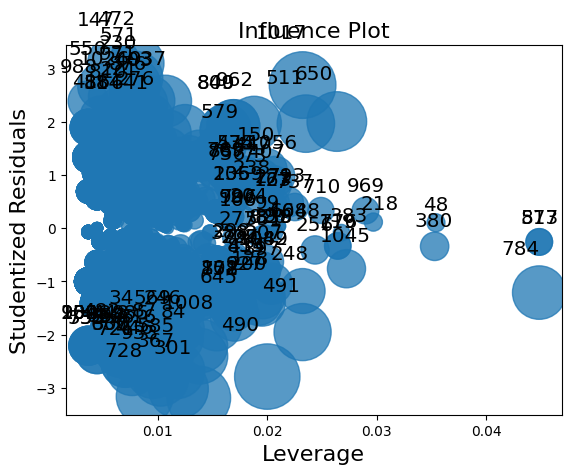

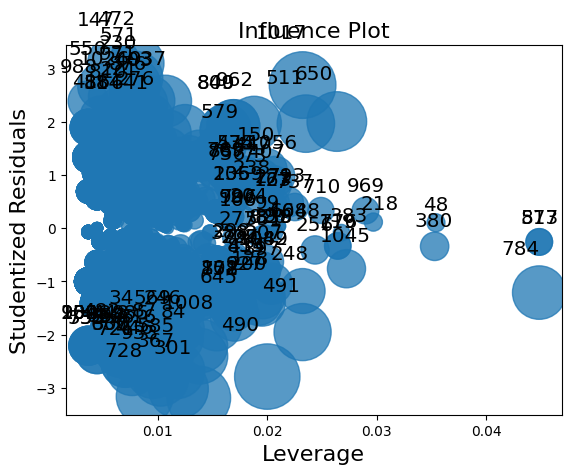

In [6]:
infl  = fit.get_influence()
cooks = infl.cooks_distance[0]
flag  = np.where(cooks > 4 / fit.nobs)[0]             # common rule of thumb
sm.graphics.influence_plot(fit, criterion="dffits")   # the DFFITS plot from class
# R equivalent: performance::check_outliers(fit)

## Linearity

Linearity just means the relationship between the predictors and the outcome is a straight-line one. For the linear model we checked this with the partial regression plots in Exercise 10 -- and it's why we logged the skewed columns like price and age first.

(np.float64(0.8854731103588132), np.float64(0.9216926502137206))

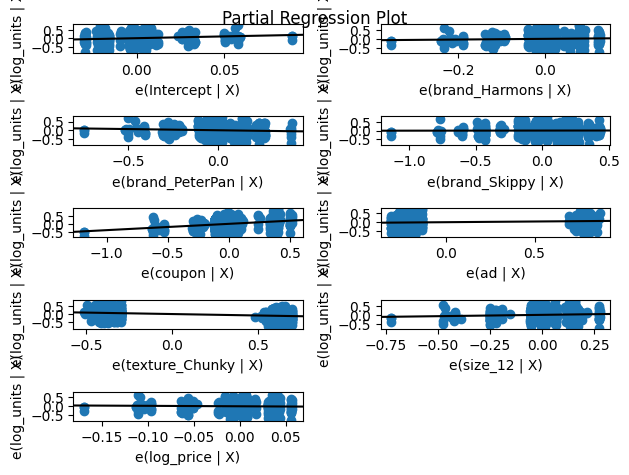

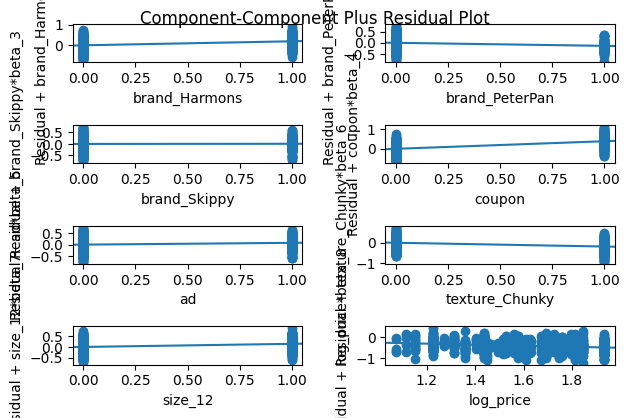

In [7]:
sm.graphics.plot_partregress_grid(fit)   # partial regression plots (from class)
sm.graphics.plot_ccpr_grid(fit)          # component + residual; better for spotting curves
linear_rainbow(fit)                      # (F, p); p > .05 means the straight-line form is fine
# linear_harvey_collier(fit)   # another option, but errors on models with many 0/1 dummy columns

For logistic regression the same idea applies, but on the log-odds scale instead of the raw outcome. `statsmodels` doesn't have a built-in for this, so here's a small binned-residuals helper (the Gelman-Hill approach): group the data by predicted probability and check that the average error in each bin stays near zero. A clear pattern (like a U-shape) means a predictor probably needs a transformation.

In [8]:
def binned_residuals(y, p, n_bins=None):   # ~ performance::binned_residuals()
    n_bins = n_bins or int(np.sqrt(len(y)))
    bins = np.array_split(np.argsort(p), n_bins)
    xb = np.array([p[b].mean() for b in bins])
    rb = np.array([(y[b] - p[b]).mean() for b in bins])
    se = np.array([np.sqrt((p[b] * (1 - p[b])).mean() / len(b)) for b in bins])
    return xb, rb, 2 * se                  # plot rb vs xb; a point outside +/- 2*se is a flag

## Independence

Independence means one observation doesn't tell us anything about another. A lot of this is just thinking about how the data was collected -- is it a random sample, are there repeat customers, is there a time order to the rows? The tests below back that up. If there's dependence (say, repeat customers), the fix is usually to add something that captures it or move to a more advanced model. Applies to both linear and logistic.

In [9]:
durbin_watson(fit.resid)                              # about 2 is fine; <1.5 or >2.5 is a warning
acorr_ljungbox(fit.resid, lags=[5], return_df=True)   # p < .05 means leftover correlation
acorr_breusch_godfrey(fit, nlags=5)                   # (LM, LM_p, F, F_p)
# R equivalent: performance::check_autocorrelation(fit)

(np.float64(7.170787956687892),
 np.float64(0.2082453116517711),
 1.7417021329416869,
 0.12227916630726865)

## Constant Variance (only for linear regression)

This one is linear-regression only. It means the spread of the residuals stays about the same across the range of predictions -- the nice cloud-like residuals-vs-fitted plot we made in class. The tests below just confirm that formally.

In [10]:
het_breuschpagan(fit.resid, fit.model.exog)   # (LM, LM_p, F, F_p); p < .05 = non-constant spread
het_white(fit.resid, fit.model.exog)          # more general version
# R equivalent: performance::check_heteroscedasticity(fit)

(np.float64(49.76601116325166),
 np.float64(0.03959426008416238),
 np.float64(1.4843839751629369),
 np.float64(0.03741157024478423))

For logistic/GLM this assumption doesn't apply, because the spread is already built into the model. The equivalent worry there is *dispersion* -- whether the actual spread is bigger than the model assumes.

In [11]:
# GLM version of the same worry: is the spread bigger than the model expects?
# (most meaningful for count/Poisson models; shown here on the demo logistic fit)
disp = (fit_logit.resid_pearson ** 2).sum() / fit_logit.df_resid   # about 1 is fine; >1 = overdispersed
# R equivalent: performance::check_overdispersion(fit)

## Normality (only for linear regression)

Also linear-regression only. The residuals should look roughly normal, which we checked with the Q-Q plot in class. Don't lean too hard on the formal test -- with lots of data it almost always flags something, so the plot is the better guide.

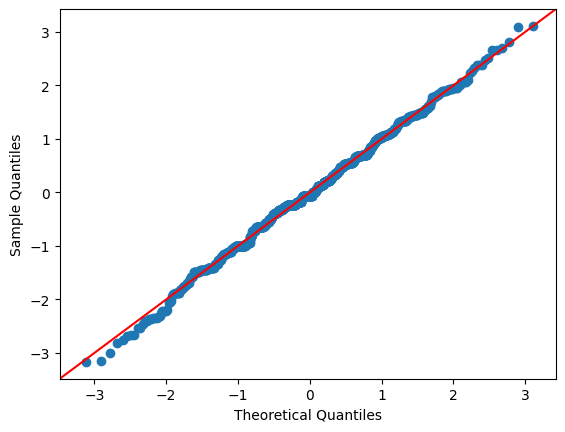

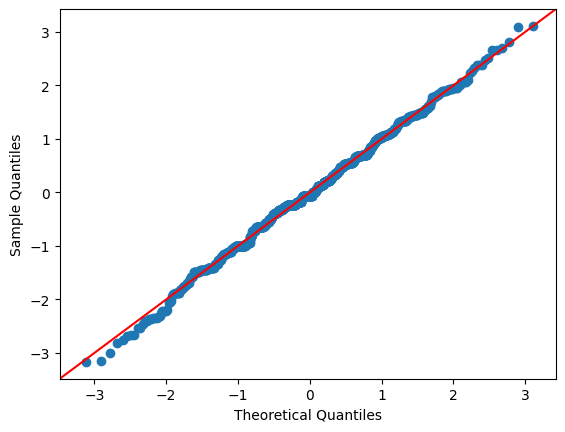

In [12]:
st.shapiro(fit.resid)                       # p < .05 = non-normal (but over-flags with lots of data)
normal_ad(fit.resid)                        # Anderson-Darling
sm.qqplot(fit.resid, line="45", fit=True)   # the Q-Q plot from class -- trust this over the test

For logistic/GLM the residuals aren't supposed to be normal, so we use the reshaping trick (quantile residuals) to put them on a scale where they *should* look uniform, then check that the same way with a Q-Q plot.

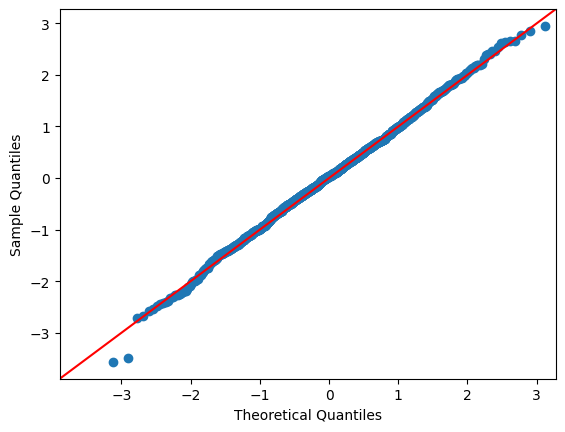

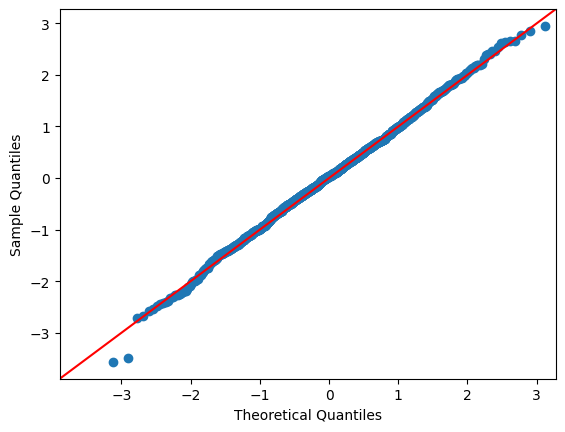

In [13]:
# GLM version: reshaped residuals should look Uniform(0,1) instead of Normal
u = rq_resid(y_logit, fit_logit.predict(), family="bernoulli")   # the demo logistic fit
st.kstest(u, "uniform")                                          # p < .05 = wrong distribution
sm.qqplot(st.norm.ppf(u), line="45")                             # reads just like a normal Q-Q plot
# R equivalent: performance::check_residuals(simulate_residuals(fit))

## Identifiability

Identifiability is about predictors that overlap too much, so the model can't tell their effects apart. This is exactly the VIF problem from Exercise 10, where `log_avg_spend` and `log_points` had huge VIFs (around 175 and 37) because they were tangled up with `log_age`. A rough guide: VIF under 5 is low, 5-10 is moderate, over 10 is a problem. The fix is to drop or combine the overlapping predictors, like we did by keeping just one of them. Works the same for linear and logistic.

In [14]:
vif = {c: variance_inflation_factor(X.values, i) for i, c in enumerate(X.columns)}
X.corr()   # quick pairwise look, like the correlation check in class
# R equivalent: performance::check_collinearity(fit)

,brand_Harmons,brand_PeterPan,brand_Skippy,coupon,ad,texture_Chunky,size_12,log_price
brand_Harmons,1.000000,-0.187244,-0.327777,0.021294,0.000273,-0.040672,0.038578,-0.846891
brand_PeterPan,-0.187244,1.000000,-0.126875,0.026347,-0.008395,0.028929,0.011546,0.005874
brand_Skippy,-0.327777,-0.126875,1.000000,-0.009452,0.029434,-0.005196,0.005350,0.138763
coupon,0.021294,0.026347,-0.009452,1.000000,-0.045323,0.043416,-0.042225,-0.229342
ad,0.000273,-0.008395,0.029434,-0.045323,1.000000,0.043123,0.045202,-0.014918
texture_Chunky,-0.040672,0.028929,-0.005196,0.043416,0.043123,1.000000,-0.017147,0.029712
size_12,0.038578,0.011546,0.005350,-0.042225,0.045202,-0.017147,1.000000,-0.445276
log_price,-0.846891,0.005874,0.138763,-0.229342,-0.014918,0.029712,-0.445276,1.000000


In [15]:
# --- Diagnostic summary: print the numbers the cells above computed but didn't show ---
print("REPRESENTATIVENESS")
cooks = fit.get_influence().cooks_distance[0]
print(f"  influential points (Cook's D > 4/n): {int((cooks > 4/fit.nobs).sum())} of {int(fit.nobs)}")

print("\nLINEARITY (OLS)")
F, p = linear_rainbow(fit)
print(f"  rainbow: F={F:.3f}, p={p:.3f}  ({'OK' if p>.05 else 'possible nonlinearity'})")

print("\nINDEPENDENCE")
dw   = durbin_watson(fit.resid)
lb_p = acorr_ljungbox(fit.resid, lags=[5], return_df=True)['lb_pvalue'].iloc[0]
bg_p = acorr_breusch_godfrey(fit, nlags=5)[1]
print(f"  Durbin-Watson: {dw:.3f}  (~2 is fine)")
print(f"  Ljung-Box p:   {lb_p:.3f}  ({'OK' if lb_p>.05 else 'autocorrelation'})")
print(f"  Breusch-Godfrey p: {bg_p:.3f}  ({'OK' if bg_p>.05 else 'autocorrelation'})")

print("\nCONSTANT VARIANCE (OLS)")
bp_p = het_breuschpagan(fit.resid, fit.model.exog)[1]
w_p  = het_white(fit.resid, fit.model.exog)[1]
print(f"  Breusch-Pagan p: {bp_p:.3f}  ({'OK' if bp_p>.05 else 'heteroscedastic'})")
print(f"  White p:         {w_p:.3f}  ({'OK' if w_p>.05 else 'heteroscedastic (sensitive at large n)'})")

print("\nDISPERSION (GLM demo)")
disp = (fit_logit.resid_pearson**2).sum() / fit_logit.df_resid
print(f"  dispersion ratio: {disp:.3f}  (~1 is fine)")

print("\nNORMALITY (OLS)")
print(f"  Shapiro-Wilk p:     {st.shapiro(fit.resid).pvalue:.3f}  (over-flags at large n -> trust the Q-Q)")
print(f"  Anderson-Darling p: {normal_ad(fit.resid)[1]:.3f}")

print("\nDISTRIBUTION (GLM demo, quantile residuals)")
ks_p = st.kstest(rq_resid(y_logit, fit_logit.predict(), family='bernoulli'), 'uniform').pvalue
print(f"  KS vs uniform p: {ks_p:.3f}  ({'OK' if ks_p>.05 else 'wrong distribution'})")

print("\nIDENTIFIABILITY (VIF)")
vif = {c: variance_inflation_factor(X.values, i) for i, c in enumerate(X.columns)}
for c, v in sorted(vif.items(), key=lambda kv: -kv[1]):
    print(f"  {c:16s} {v:7.2f}")

REPRESENTATIVENESS
  influential points (Cook's D > 4/n): 59 of 1095

LINEARITY (OLS)
  rainbow: F=0.885, p=0.922  (OK)

INDEPENDENCE
  Durbin-Watson: 2.095  (~2 is fine)
  Ljung-Box p:   0.162  (OK)
  Breusch-Godfrey p: 0.208  (OK)

CONSTANT VARIANCE (OLS)
  Breusch-Pagan p: 0.197  (OK)
  White p:         0.040  (heteroscedastic (sensitive at large n))

DISPERSION (GLM demo)
  dispersion ratio: 1.040  (~1 is fine)

NORMALITY (OLS)
  Shapiro-Wilk p:     0.036  (over-flags at large n -> trust the Q-Q)
  Anderson-Darling p: 0.003

DISTRIBUTION (GLM demo, quantile residuals)
  KS vs uniform p: 0.383  (OK)

IDENTIFIABILITY (VIF)
  log_price           2.88
  texture_Chunky      1.59
  brand_Harmons       1.48
  brand_Skippy        1.38
  coupon              1.36
  size_12             1.34
  ad                  1.28
  brand_PeterPan      1.14


# Things Performance includes that we might want to imitate but haven't yet:
- One entry point or diagnostic for the whole model (check_model())
- Plain-language outputs like 'Heteroscedasticity (non-constant error variance) detected, p = 0.031'
- Result objects that both print and plot
- Generalized VIF for categorical variables -- from what I understand, performance collapses all categorical dummy columns into one VIF